In [1]:
# ============================================================
# Disease Prediction using Symptoms - LightGBM
# MedAssist AI
# ============================================================

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# LightGBM
import lightgbm as lgb

# Save Model
import joblib

In [2]:
# ============================================================
# Load Dataset
# ============================================================

DATASET_PATH = "Disease_and_Symptoms_Preprocessed.csv"

df = pd.read_csv(DATASET_PATH)

In [3]:
# ============================================================
# Dataset Information
# ============================================================

print("Dataset Shape:")
print(df.shape)

print("\n")

print(df.head())

print("\n")

print(df.info())

Dataset Shape:
(189647, 378)


         diseases  anxiety and nervousness  depression  shortness of breath  \
0  panic disorder                        1           0                    1   
1  panic disorder                        0           0                    1   
2  panic disorder                        1           1                    1   
3  panic disorder                        1           0                    0   
4  panic disorder                        1           1                    0   

   depressive or psychotic symptoms  sharp chest pain  dizziness  insomnia  \
0                                 1                 0          0         0   
1                                 1                 0          1         1   
2                                 1                 0          1         1   
3                                 1                 0          1         1   
4                                 0                 0          0         1   

   abnormal involuntary m

In [4]:
# ============================================================
# Missing Values
# ============================================================

missing = df.isnull().sum().sum()

print("Total Missing Values :", missing)

Total Missing Values : 0


In [5]:
# ============================================================
# Missing Values
# ============================================================

missing = df.isnull().sum().sum()

print("Total Missing Values :", missing)

Total Missing Values : 0


In [6]:
# ============================================================
# Number of Disease Classes
# ============================================================

print("Unique Diseases :", df["diseases"].nunique())

Unique Diseases : 773


In [7]:
# ============================================================
# Disease Distribution
# ============================================================

disease_counts = df["diseases"].value_counts()

print(disease_counts.head(20))

diseases
cystitis                          1219
nose disorder                     1218
vulvodynia                        1218
complex regional pain syndrome    1217
spondylosis                       1216
vaginal cyst                      1215
hypoglycemia                      1215
conjunctivitis due to allergy     1215
esophagitis                       1215
peripheral nerve disorder         1215
diverticulitis                    1214
gastrointestinal hemorrhage       1214
acute bronchitis                  1213
spontaneous abortion              1212
infectious gastroenteritis        1212
fungal infection of the hair      1212
pneumonia                         1212
sprain or strain                  1212
gout                              1211
strep throat                      1210
Name: count, dtype: int64


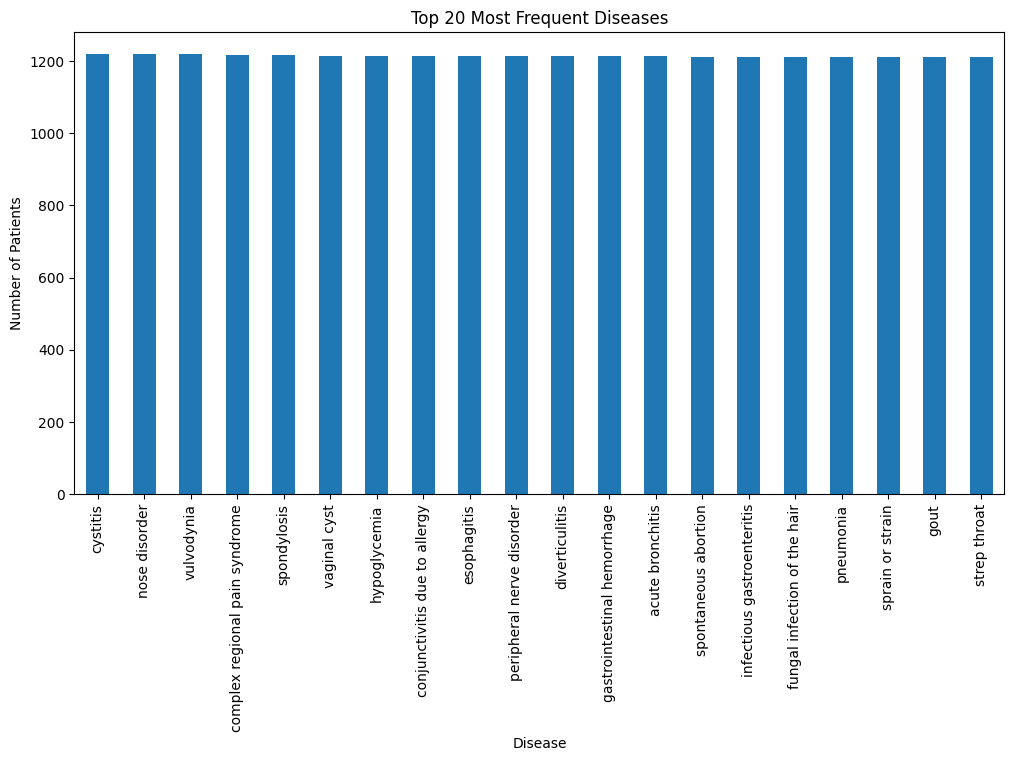

In [8]:
plt.figure(figsize=(12,6))

disease_counts.head(20).plot(kind="bar")

plt.title("Top 20 Most Frequent Diseases")

plt.xlabel("Disease")

plt.ylabel("Number of Patients")

plt.xticks(rotation=90)

plt.show()

In [9]:
# ============================================================
# Clean Column Names
# ============================================================

df.columns = (
    df.columns
    .str.replace(r"[^A-Za-z0-9_]", "_", regex=True)
    .str.replace(r"_+", "_", regex=True)
    .str.strip("_")
)

In [10]:
# ============================================================
# Remove Rare Diseases
# ============================================================

counts = df["diseases"].value_counts()

valid_classes = counts[counts >= 2].index

df = df[df["diseases"].isin(valid_classes)]

print("Dataset Shape After Removing Rare Diseases:")

print(df.shape)

print("Remaining Diseases :", df["diseases"].nunique())

Dataset Shape After Removing Rare Diseases:
(189601, 378)
Remaining Diseases : 727


In [11]:
print(df.head())

         diseases  anxiety_and_nervousness  depression  shortness_of_breath  \
0  panic disorder                        1           0                    1   
1  panic disorder                        0           0                    1   
2  panic disorder                        1           1                    1   
3  panic disorder                        1           0                    0   
4  panic disorder                        1           1                    0   

   depressive_or_psychotic_symptoms  sharp_chest_pain  dizziness  insomnia  \
0                                 1                 0          0         0   
1                                 1                 0          1         1   
2                                 1                 0          1         1   
3                                 1                 0          1         1   
4                                 0                 0          0         1   

   abnormal_involuntary_movements  chest_tightness  ... 

In [12]:
print(df.shape)

print(df["diseases"].nunique())

print(df["diseases"].value_counts().describe())

(189601, 378)
727
count     727.000000
mean      260.799175
std       338.162668
min         2.000000
25%        15.000000
50%        87.000000
75%       390.000000
max      1219.000000
Name: count, dtype: float64


In [13]:
# ============================================================
# Feature and Target
# ============================================================

X = df.drop("diseases", axis=1)

y = df["diseases"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (189601, 377)
Target Shape : (189601,)


In [14]:
# ============================================================
# Label Encoding
# ============================================================

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print("Encoded Classes :", len(encoder.classes_))

Encoded Classes : 727


In [15]:
# ============================================================
# Train Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

print("Train Classes :", len(np.unique(y_train)))
print("Test Classes :", len(np.unique(y_test)))

Training Samples : (151680, 377)
Testing Samples : (37921, 377)
Train Classes : 727
Test Classes : 698


In [16]:
print(X_train.dtypes.unique())

[dtype('int64')]


In [17]:
print(X_train.head())

        anxiety_and_nervousness  depression  shortness_of_breath  \
161665                        0           0                    0   
74173                         1           1                    0   
120238                        0           1                    0   
137246                        0           0                    0   
26926                         0           0                    0   

        depressive_or_psychotic_symptoms  sharp_chest_pain  dizziness  \
161665                                 0                 0          0   
74173                                  0                 0          1   
120238                                 1                 0          0   
137246                                 0                 0          0   
26926                                  0                 0          0   

        insomnia  abnormal_involuntary_movements  chest_tightness  \
161665         0                               0                0   
74173         

In [18]:
print(X_train.shape)

print(X_test.shape)

print(X_train.dtypes.unique())

print(X_train.head())

(151680, 377)
(37921, 377)
[dtype('int64')]
        anxiety_and_nervousness  depression  shortness_of_breath  \
161665                        0           0                    0   
74173                         1           1                    0   
120238                        0           1                    0   
137246                        0           0                    0   
26926                         0           0                    0   

        depressive_or_psychotic_symptoms  sharp_chest_pain  dizziness  \
161665                                 0                 0          0   
74173                                  0                 0          1   
120238                                 1                 0          0   
137246                                 0                 0          0   
26926                                  0                 0          0   

        insomnia  abnormal_involuntary_movements  chest_tightness  \
161665         0                       

In [19]:
# ============================================================
# Duplicate Symptom Patterns
# ============================================================

duplicates = X.duplicated().sum()

print("Duplicate Symptom Patterns :", duplicates)

Duplicate Symptom Patterns : 19743


In [22]:
# ============================================================
# Conflicting Labels
# ============================================================

group = df.groupby(list(X.columns))["diseases"].nunique()

conflicts = (group > 1).sum()

print("Conflicting Symptom Patterns :", conflicts)

Conflicting Symptom Patterns : 12626


In [23]:
# ============================================================
# Average Active Symptoms
# ============================================================

symptoms_per_patient = X.sum(axis=1)

print(symptoms_per_patient.describe())

count    189601.000000
mean          5.410362
std           1.676952
min           1.000000
25%           4.000000
50%           5.000000
75%           7.000000
max          12.000000
dtype: float64


In [20]:
print("Duplicate Symptom Patterns :", X.duplicated().sum())

group = df.groupby(list(X.columns))["diseases"].nunique()
print("Conflicting Symptom Patterns :", (group > 1).sum())

print(X.sum(axis=1).describe())

Duplicate Symptom Patterns : 19743
Conflicting Symptom Patterns : 12626
count    189601.000000
mean          5.410362
std           1.676952
min           1.000000
25%           4.000000
50%           5.000000
75%           7.000000
max          12.000000
dtype: float64


In [ ]:
# ============================================================
# Train LightGBM
# ============================================================

import time

start = time.time()

model = lgb.LGBMClassifier(
    objective="multiclass",
    boosting_type="gbdt",
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    verbosity=1
)

model.fit(X_train, y_train)

end = time.time()

print(f"Training Time: {end-start:.2f} seconds")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.271524 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 624
[LightGBM] [Info] Number of data points in the train set: 151680, number of used features: 312
[LightGBM] [Info] Start training from score -8.463792
[LightGBM] [Info] Start training from score -6.572942
[LightGBM] [Info] Start training from score -7.133738
[LightGBM] [Info] Start training from score -10.543234
[LightGBM] [Info] Start training from score -7.054331
[LightGBM] [Info] Start training from score -9.983618
[LightGBM] [Info] Start training from score -9.850087
[LightGBM] [Info] Start training from score -8.933796
[LightGBM] [Info] Start training from score -6.428270
[LightGBM] [Info] Start training from score -5.458729
[LightGBM] [Info] Start training from score -5.059475
[LightGBM] [Info] Start training from score -5.0522

Exception ignored on calling ctypes callback function <function _log_callback at 0x000001BDF0E45260>:
Traceback (most recent call last):
  File "C:\Users\KAUSHIKA G\AppData\Local\Programs\Python\Python313\Lib\site-packages\lightgbm\basic.py", line 287, in _log_callback
    def _log_callback(msg: bytes) -> None:
KeyboardInterrupt: 


No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

Exception ignored on calling ctypes callback function <function _log_callback at 0x000001BDF0E45260>:
Traceback (most recent call last):
  File "C:\Users\KAUSHIKA G\AppData\Local\Programs\Python\Python313\Lib\site-packages\lightgbm\basic.py", line 287, in _log_callback
    def _log_callback(msg: bytes) -> None:
KeyboardInterrupt: 


No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

Exception ignored on calling ctypes callback function <function _log_callback at 0x000001BDF0E45260>:
Traceback (most recent call last):
  File "C:\Users\KAUSHIKA G\AppData\Local\Programs\Python\Python313\Lib\site-packages\lightgbm\basic.py", line 287, in _log_callback
    def _log_callback(msg: bytes) -> None:
KeyboardInterrupt: 


No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

In [28]:
# Predict on test data
y_pred = model.predict(X_test)

In [29]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.0148
Precision: 0.0272
Recall   : 0.0148
F1 Score : 0.0075


In [30]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix Shape:", cm.shape)

Confusion Matrix Shape: (698, 698)


In [31]:
print("Original Diseases :", df["diseases"].nunique())
print("Encoded Classes :", len(encoder.classes_))
print("Train Classes :", len(np.unique(y_train)))
print("Test Classes :", len(np.unique(y_test)))
print("Predicted Classes :", len(np.unique(y_pred)))

Original Diseases : 727
Encoded Classes : 727
Train Classes : 727
Test Classes : 698
Predicted Classes : 61


In [32]:
print("Minimum label:", y_encoded.min())
print("Maximum label:", y_encoded.max())

Minimum label: 0
Maximum label: 726


In [33]:
print(df.groupby("diseases").size().sort_values().head(20))

diseases
uterine cancer                            2
testicular cancer                         2
spherocytosis                             2
premature rupture of amniotic membrane    2
poisoning due to antipsychotics           2
pelvic fistula                            2
pemphigus                                 2
open wound of the shoulder                2
oral leukoplakia                          2
obesity                                   2
open wound of the abdomen                 2
moyamoya disease                          2
myelodysplastic syndrome                  2
necrotizing fasciitis                     2
hyperlipidemia                            2
histoplasmosis                            2
amyloidosis                               2
heart contusion                           2
granuloma inguinale                       2
friedrich ataxia                          2
dtype: int64


In [34]:
import joblib

joblib.dump(model, "lightgbm_disease_model.pkl")

print("LightGBM model saved successfully!")

LightGBM model saved successfully!


In [35]:
joblib.dump(encoder, "label_encoder.pkl")

print("Label Encoder saved successfully!")

Label Encoder saved successfully!


In [36]:
results = {
    "Model": "LightGBM",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

results_df = pd.DataFrame([results])

results_df.to_csv("lightgbm_results.csv", index=False)

print(results_df)

      Model  Accuracy  Precision   Recall  F1 Score
0  LightGBM   0.01482   0.027155  0.01482  0.007512
